In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [4]:
# STEP 1: LOAD LOCAL DATA & CATEGORICAL ENCODING
# Load your local downloaded Kaggle insurance dataset
df = pd.read_csv('insurance.csv')

print("Insurance Dataset Loaded")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.head(3))

# Convert text features ('sex', 'smoker', 'region') into numbers using One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# Define our features (X) and our target continuous metric 'charges' (y)
X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

# Split data into 80% training and 20% testing vaults
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Insurance Dataset Loaded
Dataset Shape: 1338 rows, 7 columns

   age     sex    bmi  children smoker     region     charges
0   19  female  27.90         0    yes  southwest  16884.9240
1   18    male  33.77         1     no  southeast   1725.5523
2   28    male  33.00         3     no  southeast   4449.4620


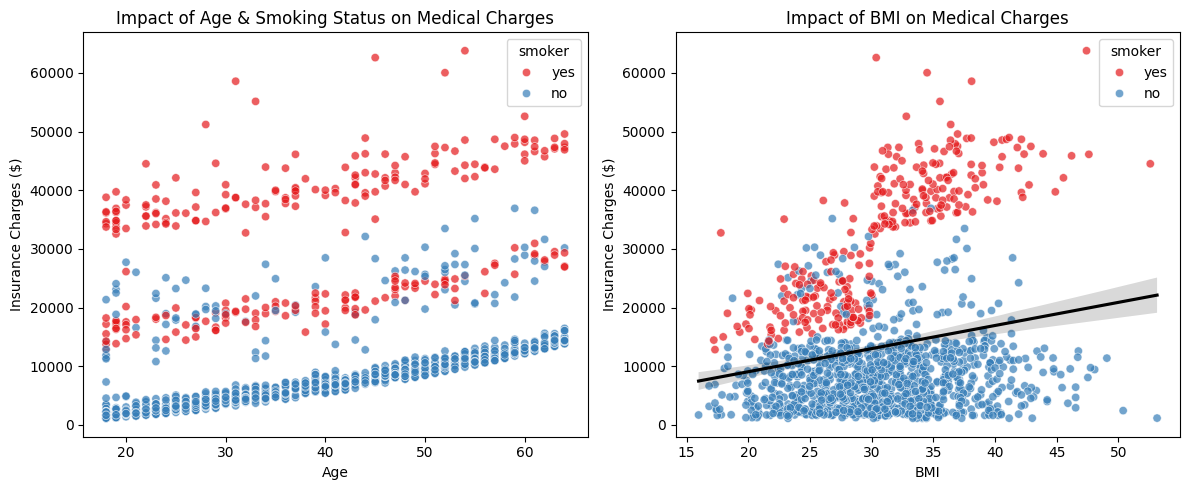

In [11]:
# STEP 2: FEATURE VISUALIZATION (Age, BMI, Smoking Impact)
# We will construct a multi-plot layout to fulfill the visualization criteria perfectly
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graph 1: Scatter plot showing Age vs Charges, colored by Smoking Status
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7, ax=axes[0])
axes[0].set_title('Impact of Age & Smoking Status on Medical Charges')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Insurance Charges ($)')

# Graph 2: Scatter plot showing BMI vs Charges with a linear regression line trend
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', palette='Set1', alpha=0.7, ax=axes[1])
# Draw a trend line showing the general trajectory of BMI costs
sns.regplot(data=df, x='bmi', y='charges', scatter=False, color='black', ax=axes[1])
axes[1].set_title('Impact of BMI on Medical Charges')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Insurance Charges ($)')
plt.tight_layout()
plt.show()

In [12]:
# STEP 3: TRAIN THE LINEAR REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
# STEP 4: MODEL PERFORMANCE EVALUATION (MAE & RMSE)
y_pred = model.predict(X_test)
# Calculate MAE and RMSE metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("     INSURANCE PRICE PREDICTION EVALUATION        ")
print(f"Mean Absolute Error (MAE):  ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")

     INSURANCE PRICE PREDICTION EVALUATION        
Mean Absolute Error (MAE):  $4181.19
Root Mean Squared Error (RMSE): $5796.28
